# Comprehensive Simulation Study: Parameter Recovery, Coverage, and Model Discrimination

Inject data from 9 truth scenarios (3 models × 3 signal strengths) and recover with all 3 models.

**Truth models**: SPL, BPL, Cutoff
**Signal strengths**: Easy (high φ), Medium (base φ), Hard (low φ)

**Metrics**: 
- Parameter recovery (bias, coverage, CI width)
- MCMC convergence (R-hat)
- Model discrimination (Bayes factors)
- Discovery curve (when does recovery become reliable?)

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaln

from load_config import load_config
from simulator import generate_single_season, signal_counts_for_model, E_REF
from posteriors import log_posterior_base, grad_log_posterior_base
from samplers import (
    run_mala,
    run_multiple_chains,
    build_spectral_logpost_and_grad,
    make_theta_init_for_model,
    posterior_summary_multi,
    _stack_chains,
    split_rhat,
)
from bridge_sampling import estimate_log_ml

In [2]:
cfg = copy.deepcopy(load_config())
test_cfg = cfg['testing']

# Lightweight defaults for notebook iteration; increase for publish-quality convergence
N_CHAINS = 4
N_ITER = 4000
N_BURN = 1500
PRIOR_TYPE = 'weakly'
SEEDS = [0, 1]

# Single-question study: can SPL injection recover gamma under the SPL inference model?
STUDY_QUESTION = 'spl_gamma_recovery'
TRUTH_MODELS = ['power_law']
INFER_MODELS = ['power_law']
PHI_MULTS = [0.3, 1.0, 3.0]
GAMMA_GRID = [2.0, 2.5, 3.0]

TRUTH_SCENARIOS = [
    (truth_model, f'phi={phi_mult:g}', float(phi_mult), f'gamma={gamma_val:g}', float(gamma_val))
    for truth_model in TRUTH_MODELS
    for phi_mult in PHI_MULTS
    for gamma_val in GAMMA_GRID
]

print('Config loaded.')
print(f'Question: {STUDY_QUESTION}')
print(f'N_CHAINS={N_CHAINS}, N_ITER={N_ITER}, N_BURN={N_BURN}, PRIOR_TYPE={PRIOR_TYPE}')
print(f'Scenarios: {len(TRUTH_SCENARIOS)} x seeds {len(SEEDS)} = {len(TRUTH_SCENARIOS) * len(SEEDS)}')


Config loaded.
Question: spl_gamma_recovery
N_CHAINS=4, N_ITER=4000, N_BURN=1500, PRIOR_TYPE=weakly
Scenarios: 9 x seeds 2 = 18


In [3]:
def get_injection_params(truth_model, phi_mult, gamma_val, config=None):
    """Get injection parameters for a given truth model, signal strength, and spectral index."""
    if config is None:
        config = load_config()
    sig_cfg = config['signal']
    phi_base = float(sig_cfg['phi'])
    if truth_model == 'power_law':
        return {
            'phi': phi_base * phi_mult,
            'gamma': float(gamma_val),
            'gamma2': float(sig_cfg['gamma2']),
            'E_break': float(sig_cfg['E_break']),
            'E_cut': float(sig_cfg['E_cut']),
        }
    if truth_model == 'broken_power_law':
        gamma1 = float(gamma_val)
        gamma2 = gamma1 + 0.5
        e_break = 100_000
        phi_sim = (phi_base * phi_mult) * (E_REF / e_break) ** (gamma2 - gamma1)
        return {
            'phi': phi_sim,
            'gamma': gamma1,
            'gamma2': gamma2,
            'E_break': e_break,
            'E_cut': float(sig_cfg['E_cut']),
        }
    if truth_model == 'cutoff':
        e_cut = 5e6
        return {
            'phi': phi_base * phi_mult,
            'gamma': float(gamma_val),
            'gamma2': float(sig_cfg['gamma2']),
            'E_break': float(sig_cfg['E_break']),
            'E_cut': e_cut,
        }
    raise ValueError(f'Unknown truth_model: {truth_model}')
def compute_rhat(results, param_names):
    """Compute max R-hat for convergence check."""
    stacked = _stack_chains(results)
    rhats = []
    for j in range(stacked.shape[2]):
        rhats.append(split_rhat(stacked[:, :, j]))
    return float(np.nanmax(rhats))
def _extract_gamma_metrics(summary, recover_model, inj_params):
    """Model-aware gamma metric extraction.
    - SPL truth/recovery: gamma
    - Cutoff truth/recovery: gamma
    - BPL truth/recovery: gamma1 (stored as 'gamma' in this code) and gamma2
    """
    out = {}
    if recover_model in ('power_law', 'cutoff'):
        key = 'gamma'
        if key in summary:
            true_val = float(inj_params['gamma'])
            lo = float(summary[key]['ci_lower'])
            hi = float(summary[key]['ci_upper'])
            mu = float(summary[key]['mean'])
            out.update({
                'gamma_param': key,
                'gamma_true': true_val,
                'gamma_mean': mu,
                'gamma_bias': mu - true_val,
                'gamma_ci_lo': lo,
                'gamma_ci_hi': hi,
                'gamma_ci_width': hi - lo,
                'gamma_covered': bool(lo <= true_val <= hi),
            })
    elif recover_model == 'broken_power_law':
        if 'gamma' in summary:
            true_val = float(inj_params['gamma'])
            lo = float(summary['gamma']['ci_lower'])
            hi = float(summary['gamma']['ci_upper'])
            mu = float(summary['gamma']['mean'])
            out.update({
                'gamma_param': 'gamma1',
                'gamma_true': true_val,
                'gamma_mean': mu,
                'gamma_bias': mu - true_val,
                'gamma_ci_lo': lo,
                'gamma_ci_hi': hi,
                'gamma_ci_width': hi - lo,
                'gamma_covered': bool(lo <= true_val <= hi),
            })
        if 'gamma2' in summary:
            true_val2 = float(inj_params['gamma2'])
            lo2 = float(summary['gamma2']['ci_lower'])
            hi2 = float(summary['gamma2']['ci_upper'])
            mu2 = float(summary['gamma2']['mean'])
            out.update({
                'gamma2_true': true_val2,
                'gamma2_mean': mu2,
                'gamma2_bias': mu2 - true_val2,
                'gamma2_ci_lo': lo2,
                'gamma2_ci_hi': hi2,
                'gamma2_ci_width': hi2 - lo2,
                'gamma2_covered': bool(lo2 <= true_val2 <= hi2),
            })
    return out
def run_one_scenario(truth_model, phi_mult, gamma_val, seed, cfg):
    """Inject truth_model with given phi_mult and gamma_val, fit all 3 models, return metrics."""
    rng = np.random.default_rng(seed)
    sig_cfg = cfg['signal']
    bg_cfg = cfg['background']
    bins_cfg = cfg['energy_bins']
    atmo_cfg = cfg['atmospheric_realism']
    det_cfg = cfg['detector_response']
    prior_phys_cfg = cfg['priors']['physics']
    inj_params = get_injection_params(truth_model, phi_mult, gamma_val, cfg)
    eta_prompt = float(
        bg_cfg.get('eta_prompt', float(bg_cfg['eta']) * float(atmo_cfg.get('prompt_fraction', 0.0)))
    )
    ds = generate_single_season(
        phi=float(inj_params['phi']),
        gamma=float(inj_params['gamma']),
        eta=float(bg_cfg['eta']),
        delta=float(bg_cfg['delta']),
        truth_model=truth_model,
        n_bins=int(bins_cfg['n_bins']),
        E_min=float(bins_cfg['E_min']),
        E_max=float(bins_cfg['E_max']),
        gamma2=float(inj_params['gamma2']),
        E_break=float(inj_params['E_break']),
        E_cut=float(inj_params['E_cut']),
        atmo_model=atmo_cfg['model'],
        prompt_fraction=float(atmo_cfg['prompt_fraction']),
        eta_prompt=eta_prompt,
        delta_prompt=float(atmo_cfg['delta_prompt']),
        E_knee=float(atmo_cfg['E_knee']),
        knee_sharpness=float(atmo_cfg['knee_sharpness']),
        prompt_prior_log_mean=float(atmo_cfg.get('prompt_prior_log_mean', np.log(1e-6))),
        prompt_prior_log_sd=float(atmo_cfg.get('prompt_prior_log_sd', 1.0)),
        prior_phi_log_mean=float(prior_phys_cfg['phi_log_mean']),
        prior_phi_log_sd=float(prior_phys_cfg['phi_log_sd']),
        prior_gamma_mean=float(prior_phys_cfg['gamma_mean']),
        prior_gamma_sd=float(prior_phys_cfg['gamma_sd']),
        prior_eta_log_mean=float(prior_phys_cfg['eta_log_mean']),
        prior_eta_log_sd=float(prior_phys_cfg['eta_log_sd']),
        prior_delta_mean=float(prior_phys_cfg['delta_mean']),
        prior_delta_sd=float(prior_phys_cfg['delta_sd']),
        detector_mode=det_cfg['mode'],
        livetime_years=float(det_cfg['livetime_years']),
        sigma_log10=float(det_cfg['sigma_log10']),
        physical_flux_units=bool(det_cfg.get('physical_flux_units', False)),
        hese75_aeff_allsky_path=det_cfg.get('hese75_aeff_allsky_path', None),
        hese75_migration_path=det_cfg.get('hese75_migration_path', None),
        hese75_sky_factor_sr=float(det_cfg.get('hese75_sky_factor_sr', 4.0 * np.pi)),
        rng=rng,
    )
    n_events = int(np.sum(ds.counts))
    true_values = {k: v for k, v in ds.true_params.items()}
    results_dict = {}
    for recover_model in INFER_MODELS:
        logpost, grad_logpost, param_names = build_spectral_logpost_and_grad(
            ds, recover_model=recover_model, prior_type=PRIOR_TYPE, eps=1e-5
        )
        theta_init = make_theta_init_for_model(ds, recover_model, param_names, sig_cfg)
        results = run_multiple_chains(
            run_mala,
            theta_init=theta_init,
            n_chains=N_CHAINS,
            init_strategy='jitter',
            init_scale=0.05,
            rng=rng,
            log_posterior_fn=logpost,
            grad_log_posterior_fn=grad_logpost,
            n_iterations=N_ITER,
            n_burnin=N_BURN,
            step_size=float(cfg['samplers']['MALA']['step_size']),
            adapt_step=bool(cfg['samplers']['MALA']['adapt_step']),
            adapt_until=int(cfg['samplers']['MALA']['adapt_until']),
            adapt_interval=int(cfg['samplers']['MALA']['adapt_interval']),
            target_accept=float(cfg['samplers']['MALA']['target_accept']),
            precond_type=str(cfg['samplers']['MALA']['precond_type']),
            normalize_precond=bool(cfg['samplers']['MALA']['normalize_precond']),
            adapt_precond=bool(cfg['samplers']['MALA']['adapt_precond']),
            param_names=param_names,
            verbose=False,
        )
        rhat = compute_rhat(results, param_names)
        summary = posterior_summary_multi(results, ci=0.90, true_values=true_values)
        samples = np.vstack([r.samples for r in results])
        log_z, _ = estimate_log_ml(logpost, samples, n_proposal=5000, n_iter=500, rng=rng, n_bootstrap=100)
        log_z += float(np.sum(gammaln(ds.counts + 1)))
        results_dict[recover_model] = {
            'rhat': rhat,
            'summary': summary,
            'log_z': log_z,
        }
    out = {
        'truth_model': truth_model,
        'phi_mult': float(phi_mult),
        'gamma_inj': float(gamma_val),
        'seed': int(seed),
        'n_events': n_events,
        'study_question': STUDY_QUESTION,
        'infer_models': ','.join(INFER_MODELS),
        'rhat_spl': float(results_dict['power_law']['rhat']) if 'power_law' in results_dict else np.nan,
        'rhat_bpl': float(results_dict['broken_power_law']['rhat']) if 'broken_power_law' in results_dict else np.nan,
        'rhat_cut': float(results_dict['cutoff']['rhat']) if 'cutoff' in results_dict else np.nan,
        'log_BF_spl_vs_bpl': (
            float(results_dict['power_law']['log_z'] - results_dict['broken_power_law']['log_z'])
            if ('power_law' in results_dict and 'broken_power_law' in results_dict) else np.nan
        ),
        'log_BF_spl_vs_cut': (
            float(results_dict['power_law']['log_z'] - results_dict['cutoff']['log_z'])
            if ('power_law' in results_dict and 'cutoff' in results_dict) else np.nan
        ),
    }
    # Recovery metrics for the matching model to truth
    model_map = {
        'power_law': 'power_law',
        'broken_power_law': 'broken_power_law',
        'cutoff': 'cutoff',
    }
    match_model = model_map[truth_model]
    metrics = _extract_gamma_metrics(results_dict[match_model]['summary'], match_model, inj_params)
    out.update(metrics)
    return out, ds


In [4]:
import pickle
from pathlib import Path

CACHE_DIR = Path('results/sim_study_cache') / STUDY_QUESTION
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CASES_FILE = CACHE_DIR / 'cases.pkl'
DF_FILE = CACHE_DIR / 'df.pkl'
CHECKPOINT_EVERY = 5

def save_results(df_data, cases_data):
    """Save dataframe and datasets to disk."""
    with open(DF_FILE, 'wb') as f:
        pickle.dump(df_data, f)
        f.flush()
    with open(CASES_FILE, 'wb') as f:
        pickle.dump(cases_data, f)
        f.flush()
    print(f'Saved results to {CACHE_DIR}')

def load_results():
    """Load dataframe and datasets from disk. Returns (df, cases) or (None, None) if not found."""
    if DF_FILE.exists() and CASES_FILE.exists():
        with open(DF_FILE, 'rb') as f:
            df_loaded = pickle.load(f)
        with open(CASES_FILE, 'rb') as f:
            cases_loaded = pickle.load(f)
        print(f'Loaded {len(df_loaded)} scenarios from cache')
        return df_loaded, cases_loaded
    return None, None


In [5]:
df_cached, cases_cached = load_results()
rows = [] if df_cached is None else df_cached.to_dict('records')
cases = {} if cases_cached is None else cases_cached

done_keys = {(str(r['truth_model']), float(r['phi_mult']), float(r['gamma_inj']), int(r['seed']) - 10_000) for r in rows}
completed = len(rows)
total = len(TRUTH_SCENARIOS) * len(SEEDS)

for truth_model, phi_name, phi_mult, gamma_name, gamma_val in TRUTH_SCENARIOS:
    for seed in SEEDS:
        key = (str(truth_model), float(phi_mult), float(gamma_val), int(seed))
        if key in done_keys:
            continue

        print(f'Truth: {truth_model:20s} {phi_name:10s} {gamma_name:12s} Seed: {seed}...')
        out, ds = run_one_scenario(truth_model, phi_mult, gamma_val, 10_000 + seed, cfg)
        rows.append(out)
        cases[key] = ds
        done_keys.add(key)
        completed += 1

        if (completed % CHECKPOINT_EVERY) == 0:
            save_results(pd.DataFrame(rows), cases)
            print(f'Checkpoint: {completed}/{total} complete')

df = pd.DataFrame(rows)
save_results(df, cases)
print()
print(f'Completed {len(df)} scenarios (target: {total})')
df.head(10)


Truth: power_law            phi=0.3    gamma=2      Seed: 0...
Truth: power_law            phi=0.3    gamma=2      Seed: 1...
Truth: power_law            phi=0.3    gamma=2.5    Seed: 0...
Truth: power_law            phi=0.3    gamma=2.5    Seed: 1...
Truth: power_law            phi=0.3    gamma=3      Seed: 0...
Saved results to results/sim_study_cache/spl_gamma_recovery
Checkpoint: 5/18 complete
Truth: power_law            phi=0.3    gamma=3      Seed: 1...
Truth: power_law            phi=1      gamma=2      Seed: 0...
Truth: power_law            phi=1      gamma=2      Seed: 1...
Truth: power_law            phi=1      gamma=2.5    Seed: 0...
Truth: power_law            phi=1      gamma=2.5    Seed: 1...
Saved results to results/sim_study_cache/spl_gamma_recovery
Checkpoint: 10/18 complete
Truth: power_law            phi=1      gamma=3      Seed: 0...
Truth: power_law            phi=1      gamma=3      Seed: 1...
Truth: power_law            phi=3      gamma=2      Seed: 0...
Truth: p

,truth_model,phi_mult,gamma_inj,seed,n_events,study_question,infer_models,rhat_spl,rhat_bpl,rhat_cut,log_BF_spl_vs_bpl,log_BF_spl_vs_cut,gamma_param,gamma_true,gamma_mean,gamma_bias,gamma_ci_lo,gamma_ci_hi,gamma_ci_width,gamma_covered
0,power_law,0.3,2.0,10000,985,spl_gamma_recovery,power_law,1.794936,NaN,NaN,NaN,NaN,gamma,2.0,2.074224,0.074224,1.798514,2.298356,0.499842,True
1,power_law,0.3,2.0,10001,996,spl_gamma_recovery,power_law,1.701422,NaN,NaN,NaN,NaN,gamma,2.0,2.225826,0.225826,1.924569,2.639244,0.714674,True
2,power_law,0.3,2.5,10000,950,spl_gamma_recovery,power_law,2.524823,NaN,NaN,NaN,NaN,gamma,2.5,2.625570,0.125570,2.251613,3.066669,0.815056,True
3,power_law,0.3,2.5,10001,969,spl_gamma_recovery,power_law,1.337026,NaN,NaN,NaN,NaN,gamma,2.5,2.800157,0.300157,2.375888,3.297491,0.921603,True
4,power_law,0.3,3.0,10000,942,spl_gamma_recovery,power_law,1.402718,NaN,NaN,NaN,NaN,gamma,3.0,2.813143,-0.186857,2.235776,3.361836,1.126060,True
5,power_law,0.3,3.0,10001,953,spl_gamma_recovery,power_law,1.886484,NaN,NaN,NaN,NaN,gamma,3.0,2.860209,-0.139791,2.451034,3.252364,0.801330,True
6,power_law,1.0,2.0,10000,1187,spl_gamma_recovery,power_law,1.702820,NaN,NaN,NaN,NaN,gamma,2.0,1.929613,-0.070387,1.753421,2.105509,0.352088,True
7,power_law,1.0,2.0,10001,1196,spl_gamma_recovery,power_law,2.035427,NaN,NaN,NaN,NaN,gamma,2.0,2.034970,0.034970,1.856035,2.230653,0.374618,True
8,power_law,1.0,2.5,10000,1072,spl_gamma_recovery,power_law,1.896637,NaN,NaN,NaN,NaN,gamma,2.5,2.348715,-0.151285,2.009960,2.792852,0.782893,True
9,power_law,1.0,2.5,10001,1081,spl_gamma_recovery,power_law,2.473277,NaN,NaN,NaN,NaN,gamma,2.5,2.756184,0.256184,2.334536,3.411658,1.077122,True


In [6]:
save_results(df, cases)


Saved results to results/sim_study_cache/spl_gamma_recovery


In [7]:
import pickle
from pathlib import Path

CACHE_DIR = Path('results/sim_study_cache') / STUDY_QUESTION
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CASES_FILE = CACHE_DIR / 'cases.pkl'
DF_FILE = CACHE_DIR / 'df.pkl'

def save_results(df_data, cases_data):
    """Save dataframe and datasets to disk."""
    with open(DF_FILE, 'wb') as f:
        pickle.dump(df_data, f)
        f.flush()
    with open(CASES_FILE, 'wb') as f:
        pickle.dump(cases_data, f)
        f.flush()
    print(f'Saved results to {CACHE_DIR}')

def load_results():
    """Load dataframe and datasets from disk. Returns (df, cases) or (None, None) if not found."""
    if DF_FILE.exists() and CASES_FILE.exists():
        with open(DF_FILE, 'rb') as f:
            df_loaded = pickle.load(f)
        with open(CASES_FILE, 'rb') as f:
            cases_loaded = pickle.load(f)
        print(f'Loaded {len(df_loaded)} scenarios from cache')
        return df_loaded, cases_loaded
    return None, None


In [8]:
# Aggregate across seeds
if 'df' not in globals() or df is None or len(df) == 0:
    df_loaded, cases_loaded = load_results()
    if df_loaded is None:
        raise RuntimeError('No in-memory df and no cache found. Run simulation cell first.')
    df = df_loaded
    if 'cases' not in globals() or cases is None:
        cases = cases_loaded

agg = (
    df.groupby(['truth_model', 'phi_mult', 'gamma_inj'], as_index=False)
    .agg({
        'n_events': 'mean',
        'rhat_spl': 'max',
        'rhat_bpl': 'max',
        'rhat_cut': 'max',
        'gamma_ci_width': 'mean',
        'gamma_covered': 'mean',
        'gamma2_ci_width': 'mean',
        'gamma2_covered': 'mean',
        'log_BF_spl_vs_bpl': 'mean',
        'log_BF_spl_vs_cut': 'mean',
    })
    .rename(columns={
        'gamma_inj': 'gamma_true',
        'gamma_covered': 'gamma_coverage',
        'gamma2_covered': 'gamma2_coverage',
        'log_BF_spl_vs_bpl': 'log_BF_bpl',
        'log_BF_spl_vs_cut': 'log_BF_cut',
    })
    .sort_values(['truth_model', 'phi_mult', 'gamma_true'])
)

print()
print('=== Sample size and convergence ===')
print(agg[['truth_model', 'phi_mult', 'gamma_true', 'n_events', 'rhat_spl', 'rhat_bpl', 'rhat_cut']].to_string(index=False))

print()
print('=== Recovery quality (gamma constraints) ===')
print(agg[['truth_model', 'phi_mult', 'gamma_true', 'gamma_ci_width', 'gamma_coverage', 'gamma2_ci_width', 'gamma2_coverage']].to_string(index=False))

print()
print('=== Model discrimination (SPL BF) ===')
print(agg[['truth_model', 'phi_mult', 'gamma_true', 'log_BF_bpl', 'log_BF_cut']].to_string(index=False))


KeyError: "Label(s) ['gamma2_ci_width', 'gamma2_covered'] do not exist"

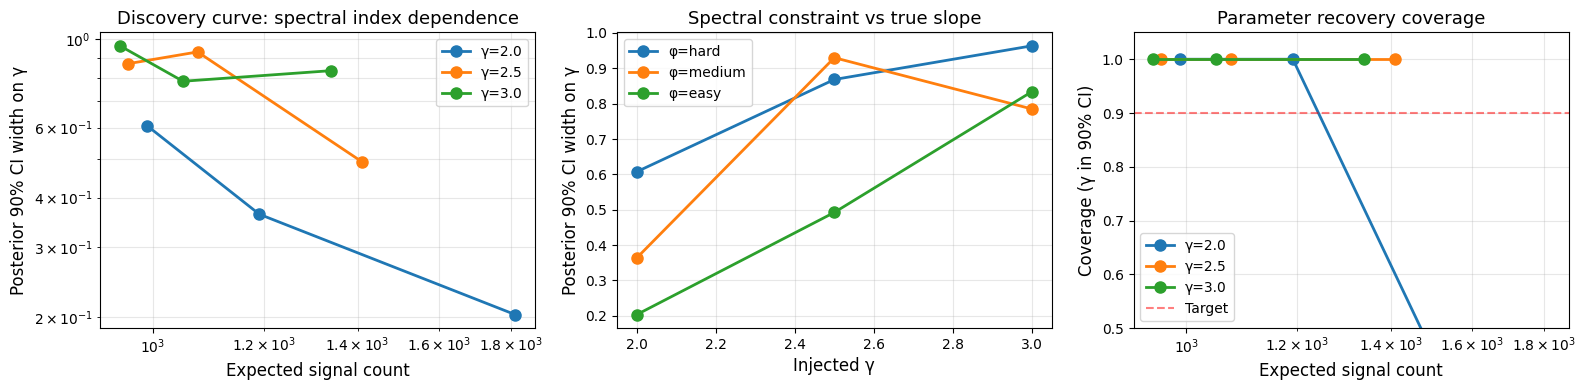


Key insights:
- Steeper γ (hard): harder to constrain (wider CI)
- Higher signal count: tighter constraints
- Coverage should be ~90% across the grid


In [ ]:
# Discovery curve: γ constraint vs BOTH signal and spectral index
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Focus on SPL truth only
spl_agg = agg[agg['truth_model'] == 'power_law']

# Left: CI width vs phi, separated by gamma
ax = axes[0]
for gamma in sorted(spl_agg['gamma_true'].unique()):
    subset = spl_agg[spl_agg['gamma_true'] == gamma].sort_values('phi_mult')
    ax.loglog(subset['n_events'], subset['gamma_ci_width'], 'o-', label=f'γ={gamma:.1f}', linewidth=2, markersize=8)
ax.set_xlabel('Expected signal count', fontsize=12)
ax.set_ylabel('Posterior 90% CI width on γ', fontsize=12)
ax.set_title('Discovery curve: spectral index dependence', fontsize=13)
ax.grid(True, alpha=0.3, which='both')
ax.legend()

# Middle: CI width vs gamma, separated by phi
ax = axes[1]
for phi in sorted(spl_agg['phi_mult'].unique()):
    subset = spl_agg[spl_agg['phi_mult'] == phi].sort_values('gamma_true')
    phi_name = 'easy' if phi > 2 else 'hard' if phi < 1 else 'medium'
    ax.plot(subset['gamma_true'], subset['gamma_ci_width'], 'o-', label=f'φ={phi_name}', linewidth=2, markersize=8)
ax.set_xlabel('Injected γ', fontsize=12)
ax.set_ylabel('Posterior 90% CI width on γ', fontsize=12)
ax.set_title('Spectral constraint vs true slope', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend()

# Right: Coverage vs phi, separated by gamma
ax = axes[2]
for gamma in sorted(spl_agg['gamma_true'].unique()):
    subset = spl_agg[spl_agg['gamma_true'] == gamma].sort_values('phi_mult')
    ax.semilogx(subset['n_events'], subset['gamma_coverage'], 'o-', label=f'γ={gamma:.1f}', linewidth=2, markersize=8)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='Target')
ax.set_xlabel('Expected signal count', fontsize=12)
ax.set_ylabel('Coverage (γ in 90% CI)', fontsize=12)
ax.set_title('Parameter recovery coverage', fontsize=13)
ax.set_ylim([0.5, 1.05])
ax.grid(True, alpha=0.3, which='both')
ax.legend()

plt.tight_layout()
plt.show()

print('\nKey insights:')
print('- Steeper γ (hard): harder to constrain (wider CI)')
print('- Higher signal count: tighter constraints')
print('- Coverage should be ~90% across the grid')

In [ ]:
# Convergence summary
print('=== Convergence Status ===')
print('R-hat values (max across parameters, per scenario):')
print('R-hat < 1.05: excellent')
print('R-hat < 1.10: good')
print('R-hat > 1.10: WARNING')

for model in ['power_law', 'broken_power_law', 'cutoff']:
    model_agg = agg[agg['truth_model'] == model]
    print(f'{model}:')
    for _, row in model_agg.iterrows():
        sig = row['phi_mult']
        g = row['gamma_true']
        rhat_spl = row['rhat_spl']
        rhat_bpl = row['rhat_bpl']
        rhat_cut = row['rhat_cut']
        status_spl = 'OK' if rhat_spl < 1.10 else 'BAD'
        status_bpl = 'OK' if rhat_bpl < 1.10 else 'BAD'
        status_cut = 'OK' if rhat_cut < 1.10 else 'BAD'
        print(f'  phi_mult={sig:.1f}, gamma={g:.1f}: SPL {status_spl} {rhat_spl:.3f} | BPL {status_bpl} {rhat_bpl:.3f} | Cut {status_cut} {rhat_cut:.3f}')


=== Convergence Status ===
R-hat values (max across parameters, per scenario):
R-hat < 1.05: excellent
R-hat < 1.10: good
R-hat > 1.10: WARNING
power_law:
  phi_mult=0.3, gamma=2.0: SPL BAD 1.795 | BPL BAD 1.944 | Cut BAD 2.836
  phi_mult=0.3, gamma=2.5: SPL BAD 2.525 | BPL BAD 2.212 | Cut BAD 2.069
  phi_mult=0.3, gamma=3.0: SPL BAD 1.886 | BPL BAD 1.870 | Cut BAD 2.436
  phi_mult=1.0, gamma=2.0: SPL BAD 2.035 | BPL BAD 4.385 | Cut BAD 1.700
  phi_mult=1.0, gamma=2.5: SPL BAD 2.473 | BPL BAD 2.507 | Cut BAD 2.456
  phi_mult=1.0, gamma=3.0: SPL BAD 1.911 | BPL BAD 2.068 | Cut BAD 2.144
  phi_mult=3.0, gamma=2.0: SPL BAD 2.052 | BPL BAD 4.277 | Cut BAD 2.375
  phi_mult=3.0, gamma=2.5: SPL BAD 2.425 | BPL BAD 3.751 | Cut BAD 3.023
  phi_mult=3.0, gamma=3.0: SPL BAD 1.515 | BPL BAD 1.909 | Cut BAD 1.794
broken_power_law:
  phi_mult=0.3, gamma=2.0: SPL BAD 2.587 | BPL BAD 2.433 | Cut BAD 2.046
  phi_mult=0.3, gamma=2.5: SPL BAD 1.827 | BPL BAD 1.797 | Cut BAD 2.436
  phi_mult=0.3, gamma=3.

KeyError: 'gamma1'

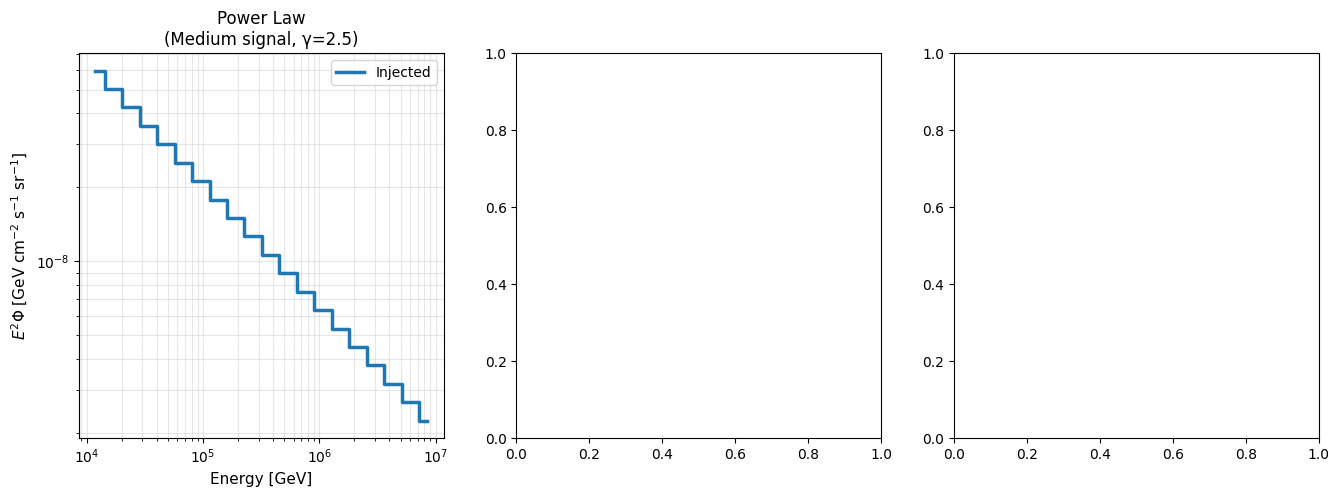

In [ ]:
# Spectral visualization: injected vs recovered for each truth model
# Use stored datasets from scan, medium signal + medium gamma, first seed

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
truth_models = ['power_law', 'broken_power_law', 'cutoff']
phi_mult = 1.0
gamma_val = 2.5
seed = 0

for ax_idx, truth_model in enumerate(truth_models):
    ax = axes[ax_idx]
    
    # Get stored dataset from scan
    key = (truth_model, phi_mult, gamma_val, seed)
    if key not in cases:
        ax.text(0.5, 0.5, f'No data for {truth_model}', ha='center', va='center')
        continue
    
    ds = cases[key]
    inj_params = get_injection_params(truth_model, phi_mult, gamma_val, cfg)
    
    # Injected spectrum
    p_inj = {k: v for k, v in inj_params.items() if k in ['phi', 'gamma', 'gamma2', 'E_break', 'E_cut']}
    mu_inj = signal_counts_for_model(ds.E_centers, ds.E_widths, truth_model, p_inj)
    phi_inj = np.clip(mu_inj / ds.E_widths, 1e-40, None)
    e2phi_inj = ds.E_centers**2 * phi_inj
    
    # Plot
    ax.step(ds.E_centers, e2phi_inj, where='mid', lw=2.5, color='tab:blue', label='Injected')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Energy [GeV]', fontsize=11)
    ax.set_ylabel(r'$E^2\Phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=11)
    ax.set_title(f'{truth_model.replace("_", " ").title()}\n(Medium signal, γ=2.5)', fontsize=12)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend()

plt.tight_layout()
plt.show()

print('Injected spectral shapes:')
print('- SPL: smooth power law')
print('- BPL: power law with bend (steepens at high E)')
print('- Cutoff: power law with exponential suppression at high E')

In [ ]:
# Bayes factor heatmap across truth scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

truth_models = sorted(agg['truth_model'].unique())
phi_mults = sorted(agg['phi_mult'].unique())

for i, bf_col in enumerate(['log_BF_bpl', 'log_BF_cut']):
    ax = axes[i]
    matrix = np.zeros((len(truth_models), len(phi_mults)))
    for j, model in enumerate(truth_models):
        for k, sig in enumerate(phi_mults):
            val = agg[(agg['truth_model'] == model) & (agg['phi_mult'] == sig)][bf_col].mean()
            matrix[j, k] = val if np.isfinite(val) else np.nan

    im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', vmin=-5, vmax=5)
    ax.set_xticks(range(len(phi_mults)))
    ax.set_xticklabels([f'{s:.1f}x' for s in phi_mults])
    ax.set_yticks(range(len(truth_models)))
    ax.set_yticklabels(truth_models)
    ax.set_xlabel('Signal strength (phi multiplier)', fontsize=12)
    ax.set_ylabel('Truth model', fontsize=12)
    ax.set_title(f'log BF (SPL vs {"-".join(bf_col.split("_")[2:])})', fontsize=13)

    for j in range(len(truth_models)):
        for k in range(len(phi_mults)):
            val = matrix[j, k]
            color = 'white' if np.isfinite(val) and abs(val) > 2 else 'black'
            ax.text(k, j, f'{val:.1f}', ha='center', va='center', color=color, fontsize=11)

    plt.colorbar(im, ax=ax, label='log BF')

plt.tight_layout()
plt.show()


In [ ]:
# Gamma-width vs effective livetime proxy (event count)
# For this fixed detector setup, n_events is proportional to livetime/exposure.

spl_only = agg[agg['truth_model'] == 'power_law'].copy()
spl_only = spl_only.sort_values(['gamma_true', 'n_events'])

fig, ax = plt.subplots(figsize=(7, 5))
for g in sorted(spl_only['gamma_true'].unique()):
    ss = spl_only[spl_only['gamma_true'] == g]
    ax.loglog(ss['n_events'], ss['gamma_ci_width'], 'o-', label=f'gamma={g:.1f}', linewidth=2)

ax.set_xlabel('Total events (proxy for livetime)')
ax.set_ylabel('90% CI width on gamma')
ax.set_title('Gamma CI width vs exposure (SPL truth)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

spl_only[['phi_mult', 'gamma_true', 'n_events', 'gamma_ci_width', 'gamma_coverage']].to_csv(
    'results/gamma_width_vs_livetime_spl.csv',
    index=False,
)
print('Saved results/gamma_width_vs_livetime_spl.csv')
